Import Libraries

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [41]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ahppp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Data loading and cleaning

In [42]:
df = pd.read_csv("fake_news_dataset.csv", encoding="utf-8")
print(df.shape)
df.head()

(72134, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [43]:
print("Missing values per column before cleaning:")
print(df.isnull().sum().sum())

Missing values per column before cleaning:
597


In [44]:
df.fillna('', inplace=True)

df['content'] = df['title'] + " " + df['text']
df_clean = df[['content', 'label']].copy()

print(f"\nMissing values after cleaning: {df_clean.isnull().sum().sum()}")
df_clean.head()


Missing values after cleaning: 0


,content,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


Class distribution (Fake or Real)

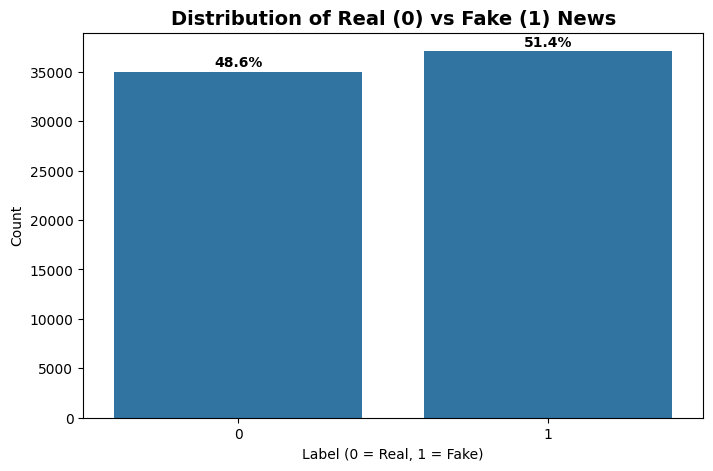

In [45]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x='label')
plt.title('Distribution of Real (0) vs Fake (1) News', fontsize=14, fontweight='bold')
plt.xlabel('Label (0 = Real, 1 = Fake)')
plt.ylabel('Count')

total = len(df_clean)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 500
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold')

plt.show()

Feature extraction and vectorization

In [46]:
port_stem = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [47]:
def stemming(content):
    stemmed_content = re.sub('[^a-zA-Z]', ' ', content)
    stemmed_content = stemmed_content.lower()
    stemmed_content = stemmed_content.split()

    stemmed_content = [
        port_stem.stem(word)
        for word in stemmed_content
        if word not in stop_words
    ]

    return ' '.join(stemmed_content)

In [48]:
df_clean['content'] = df_clean['content'].apply(stemming)

In [49]:
X = df_clean['content']
y = df_clean['label']

print("Vectorizing text data...")
vectorizer = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 2))

X_tfidf = vectorizer.fit_transform(X)

print(f"Matrix shape after Vectorization: {X_tfidf.shape}")

Vectorizing text data...
Matrix shape after Vectorization: (72134, 10000)


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 57707 samples
Test set:     14427 samples


Training the model

In [51]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [52]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
print('Training Accuracy: {:.4f}'.format(accuracy_score(y_train, train_pred)))
print('Test Accuracy: {:.4f}'.format(accuracy_score(y_test, test_pred)))

print('Classification Report:')
print(classification_report(y_test, test_pred, target_names=['Real (0)', 'Fake (1)']))

Training Accuracy: 0.9588
Test Accuracy: 0.9473
Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.95      0.94      0.95      7006
    Fake (1)       0.94      0.96      0.95      7421

    accuracy                           0.95     14427
   macro avg       0.95      0.95      0.95     14427
weighted avg       0.95      0.95      0.95     14427



In [53]:
X_new = X_test[8]

prediction = model.predict(X_new)
print(prediction)

if prediction[0] == 0:
    print('The news is Real')
else:
    print('The news is Fake')

[0]
The news is Real


In [54]:
print(y_test.iloc[8])

0
